In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv("train_LZdllcl.csv")
test = pd.read_csv("test_2umaH9m.csv")
sample = pd.read_csv("sample_submission_M0L0uXE.csv")

In [3]:
train.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


In [4]:
train.shape

(54808, 14)

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB


In [6]:
train.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.351974,0.023172,63.386750,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.477590,0.150450,13.371559,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,1.000000,99.000000,1.000000


In [7]:
train.isnull().sum()

,0
employee_id,0
department,0
region,0
education,2409
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0


In [8]:
train.duplicated().sum()

np.int64(0)

In [9]:
train["education"].value_counts()

,count
education,
Bachelor's,36669
Master's & above,14925
Below Secondary,805


In [10]:
train["previous_year_rating"].value_counts()

,count
previous_year_rating,
3.0,18618
5.0,11741
4.0,9877
1.0,6223
2.0,4225


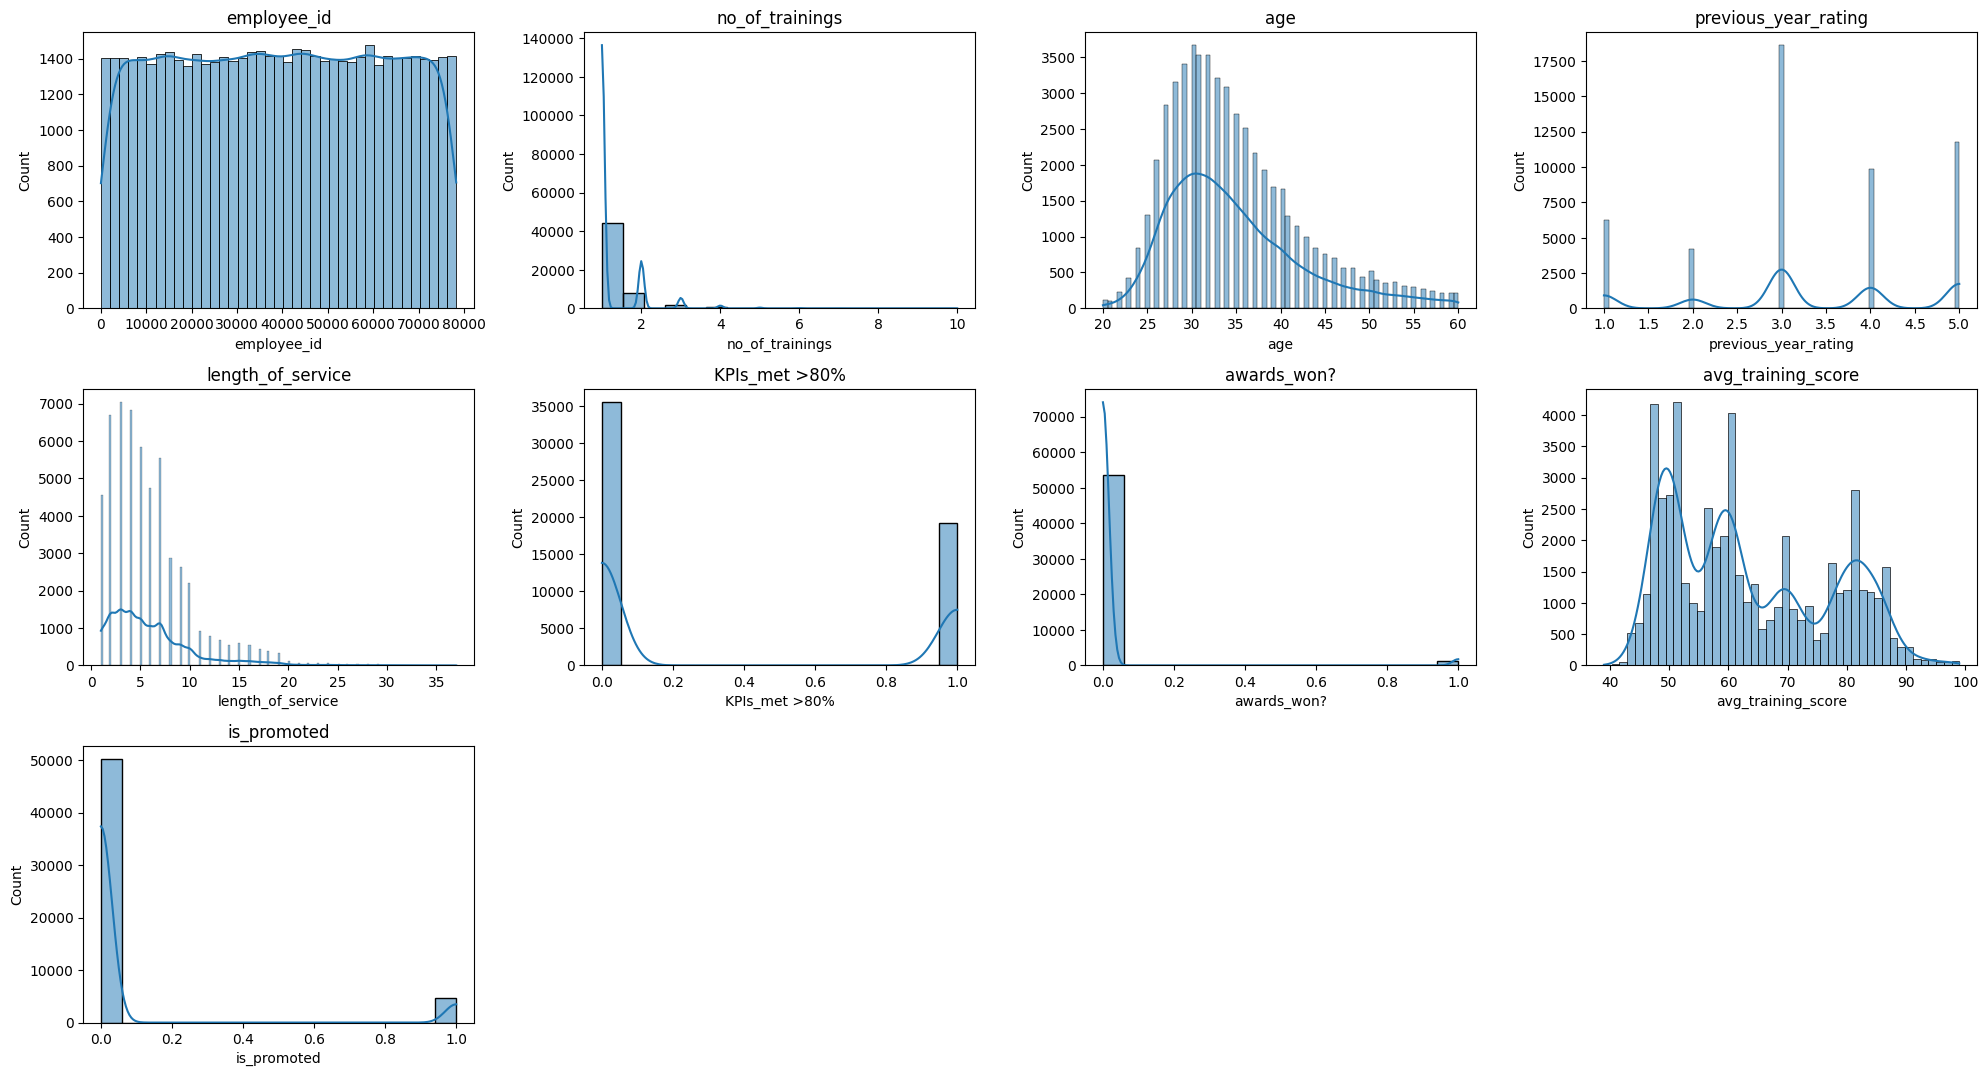

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = train.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(20, 14))

for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i + 1)
    sns.histplot(train[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

In [12]:
train["education"] = train["education"].fillna(train["education"].mode()[0])

In [13]:
train["previous_year_rating"] = train["previous_year_rating"].fillna(train["previous_year_rating"].median())

In [14]:
train.isnull().sum()

,0
employee_id,0
department,0
region,0
education,0
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,0
length_of_service,0


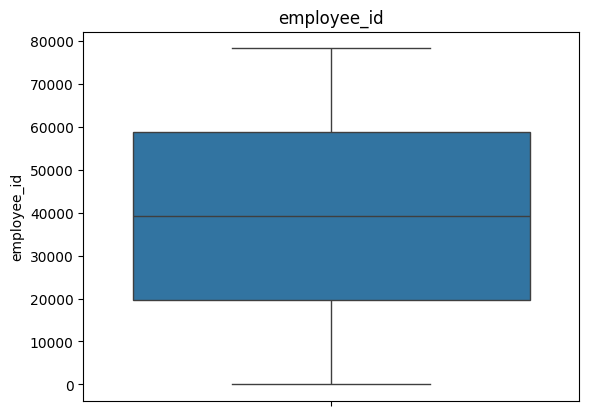

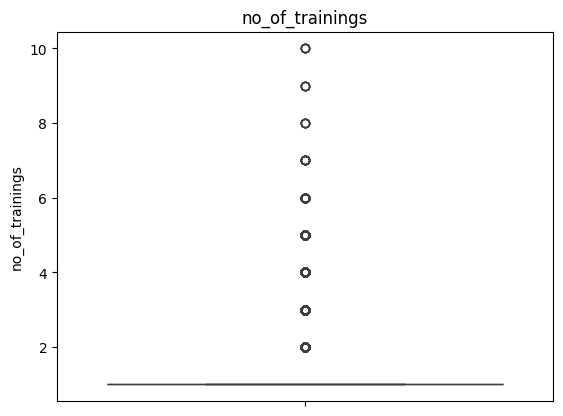

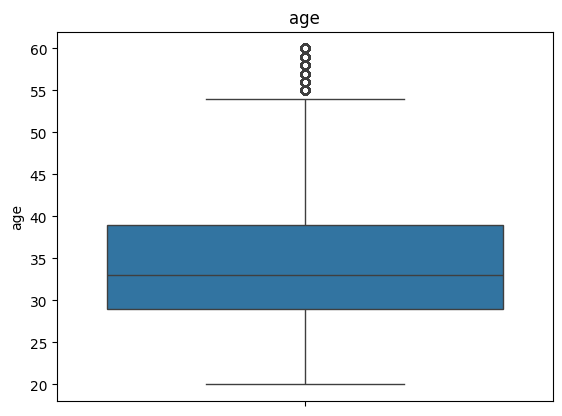

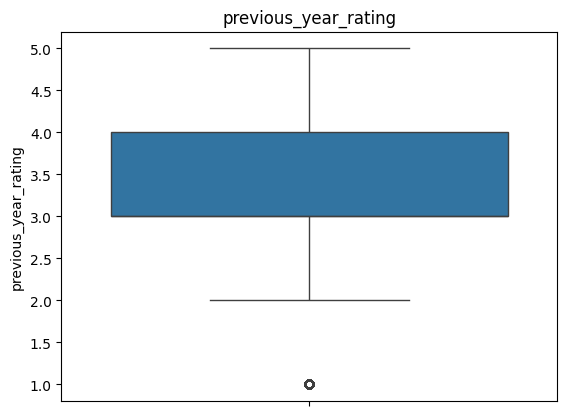

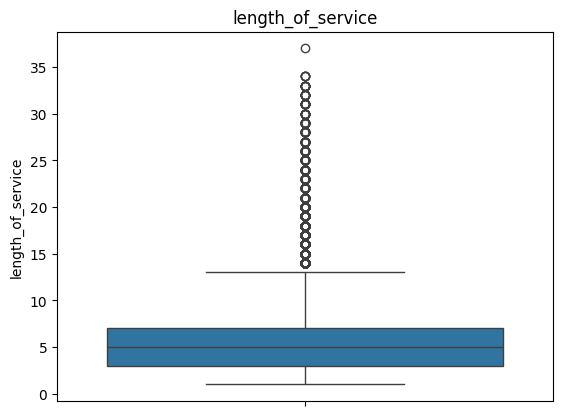

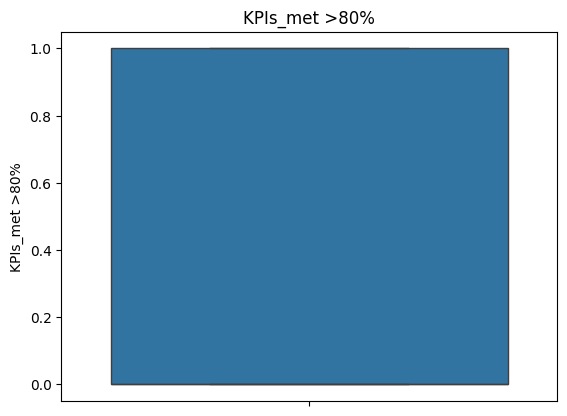

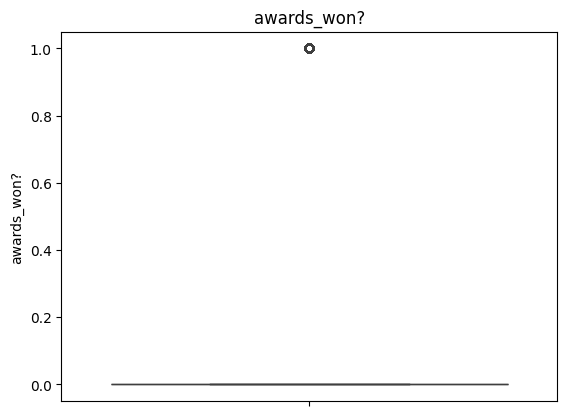

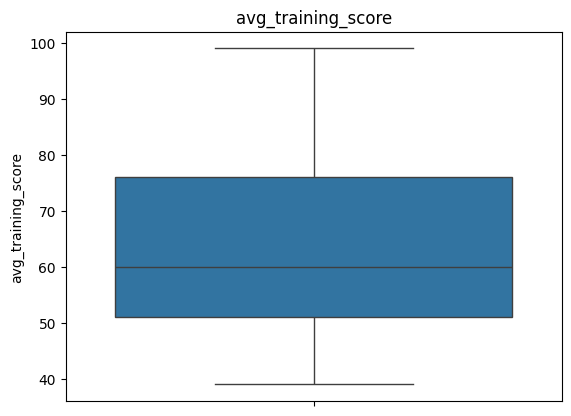

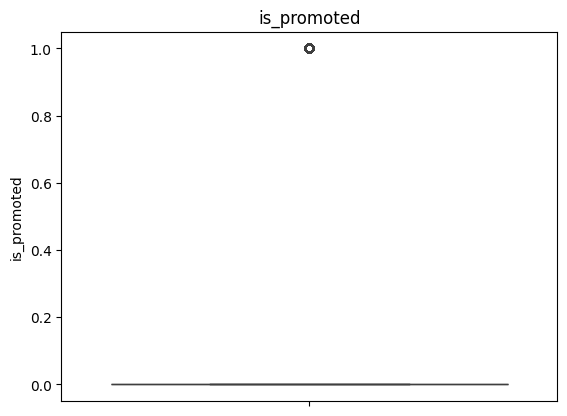

In [15]:
num_col = train.select_dtypes(include=["int64", "float64"]).columns

for col in num_col:
    sns.boxplot(y=train[col])
    plt.title(col)
    plt.show()

In [16]:
Q1 = train["previous_year_rating"].quantile(0.25)
Q3 = train["previous_year_rating"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

train["previous_year_rating"] = train["previous_year_rating"].clip(lower, upper)

In [17]:
from scipy.stats.mstats import winsorize

In [18]:
train["age"] = winsorize(train["age"], limits=[0.02, 0.02])

train["length_of_service"] = winsorize(train["length_of_service"], limits=[0.03, 0.03])

train["avg_training_score"] = winsorize(train["avg_training_score"], limits=[0.01, 0.01])

In [19]:
Q1 = train["no_of_trainings"].quantile(0.25)
Q3 = train["no_of_trainings"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

train["no_of_trainings"] = train["no_of_trainings"].clip(lower, upper)

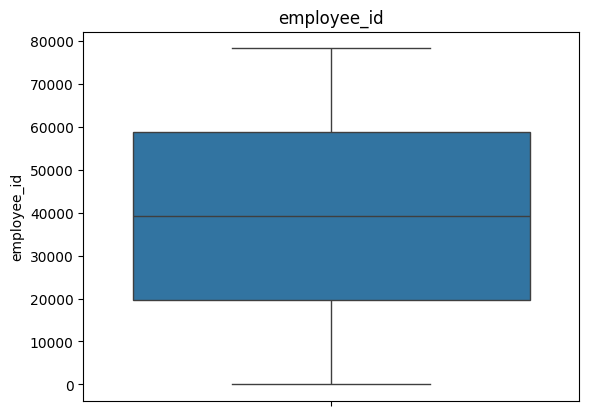

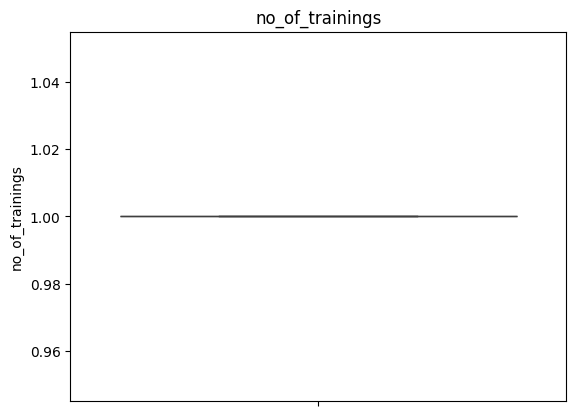

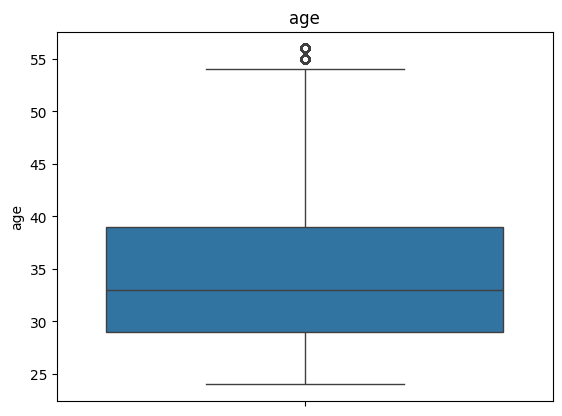

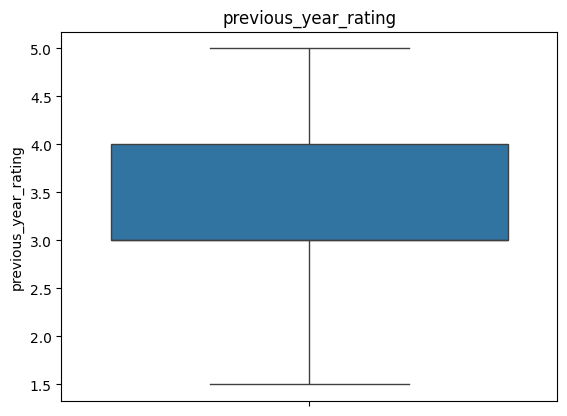

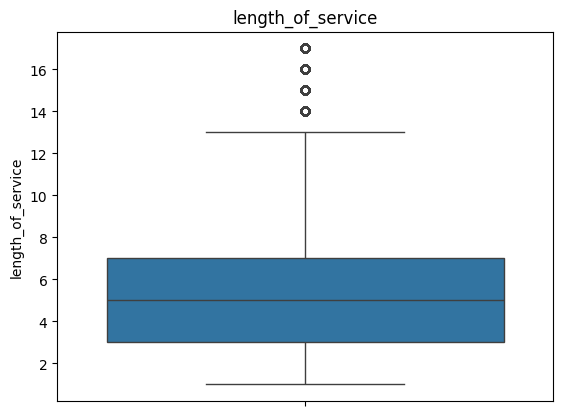

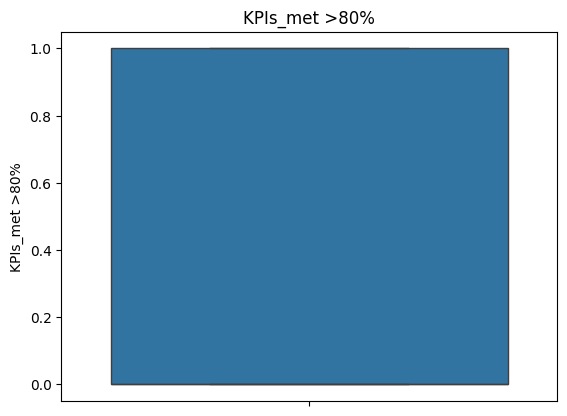

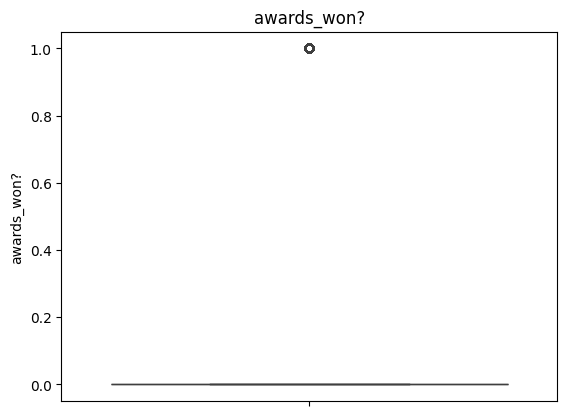

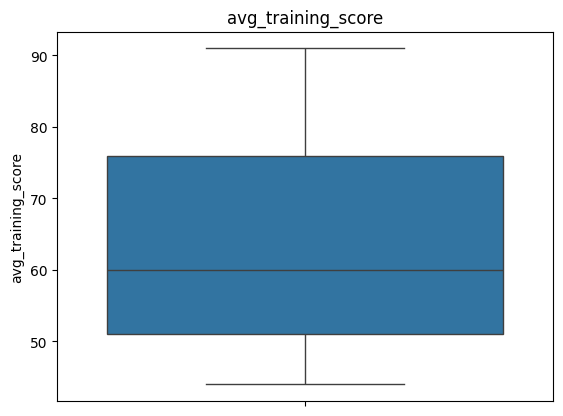

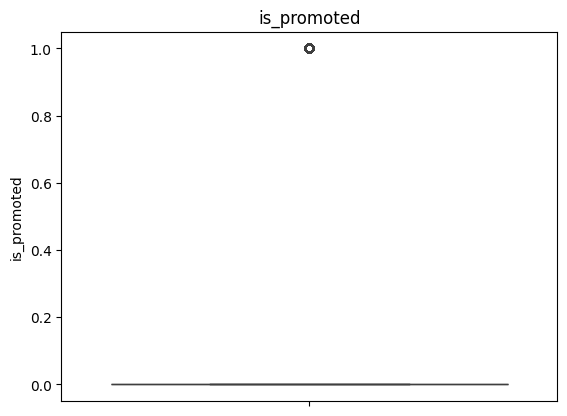

In [20]:
num_col = train.select_dtypes(include=["int64", "float64"]).columns

for col in num_col:
    sns.boxplot(y=train[col])
    plt.title(col)
    plt.show()

In [21]:
cat_col = train.select_dtypes(include="object").columns
cat_col

Index(['department', 'region', 'education', 'gender', 'recruitment_channel'], dtype='object')

In [22]:
for col in cat_col:
    print(col)
    print(train[col].unique())
    print("-------------------")

department
['Sales & Marketing' 'Operations' 'Technology' 'Analytics' 'R&D'
 'Procurement' 'Finance' 'HR' 'Legal']
-------------------
region
['region_7' 'region_22' 'region_19' 'region_23' 'region_26' 'region_2'
 'region_20' 'region_34' 'region_1' 'region_4' 'region_29' 'region_31'
 'region_15' 'region_14' 'region_11' 'region_5' 'region_28' 'region_17'
 'region_13' 'region_16' 'region_25' 'region_10' 'region_27' 'region_30'
 'region_12' 'region_21' 'region_8' 'region_32' 'region_6' 'region_33'
 'region_24' 'region_3' 'region_9' 'region_18']
-------------------
education
["Master's & above" "Bachelor's" 'Below Secondary']
-------------------
gender
['f' 'm']
-------------------
recruitment_channel
['sourcing' 'other' 'referred']
-------------------


In [23]:
train = pd.get_dummies(
    train,
    columns=["department", "region", "recruitment_channel"],
    prefix=["de", "re", "recru"],
    drop_first=True,
    dtype=int
)

In [24]:
train["gender"] = train["gender"].map({
    "m": 1,
    "f": 0
})

In [25]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[[
    "Below Secondary",
    "Bachelor's",
    "Master's & above"
]])

train[["education"]] = oe.fit_transform(train[["education"]])

In [26]:
train.head()

,employee_id,education,gender,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,...,re_region_33,re_region_34,re_region_4,re_region_5,re_region_6,re_region_7,re_region_8,re_region_9,recru_referred,recru_sourcing
0,65438,2.0,0,1,35,5.0,8,1,0,49,...,0,0,0,0,0,1,0,0,0,1
1,65141,1.0,1,1,30,5.0,4,0,0,60,...,0,0,0,0,0,0,0,0,0,0
2,7513,1.0,1,1,34,3.0,7,0,0,50,...,0,0,0,0,0,0,0,0,0,1
3,2542,1.0,1,1,39,1.5,10,0,0,50,...,0,0,0,0,0,0,0,0,0,0
4,48945,1.0,1,1,45,3.0,2,0,0,73,...,0,0,0,0,0,0,0,0,0,0


In [27]:
train.columns

Index(['employee_id', 'education', 'gender', 'no_of_trainings', 'age',
       'previous_year_rating', 'length_of_service', 'KPIs_met >80%',
       'awards_won?', 'avg_training_score', 'is_promoted', 'de_Finance',
       'de_HR', 'de_Legal', 'de_Operations', 'de_Procurement', 'de_R&D',
       'de_Sales & Marketing', 'de_Technology', 're_region_10', 're_region_11',
       're_region_12', 're_region_13', 're_region_14', 're_region_15',
       're_region_16', 're_region_17', 're_region_18', 're_region_19',
       're_region_2', 're_region_20', 're_region_21', 're_region_22',
       're_region_23', 're_region_24', 're_region_25', 're_region_26',
       're_region_27', 're_region_28', 're_region_29', 're_region_3',
       're_region_30', 're_region_31', 're_region_32', 're_region_33',
       're_region_34', 're_region_4', 're_region_5', 're_region_6',
       're_region_7', 're_region_8', 're_region_9', 'recru_referred',
       'recru_sourcing'],
      dtype='object')

In [28]:
X = train.drop(["employee_id", "is_promoted"], axis=1)
y = train["is_promoted"]

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
print("X_train:", X_train.shape)

print("y_train:", y_train.shape)


X_train: (43846, 52)
y_train: (43846,)


In [31]:
train["is_promoted"].value_counts()

,count
is_promoted,
0,50140
1,4668


In [32]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=1000
)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_valid)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [33]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_valid, y_pred))
print(confusion_matrix(y_valid, y_pred))
print(classification_report(y_valid, y_pred))

Accuracy: 0.7658274037584383
[[7625 2403]
 [ 164  770]]
              precision    recall  f1-score   support

           0       0.98      0.76      0.86     10028
           1       0.24      0.82      0.37       934

    accuracy                           0.77     10962
   macro avg       0.61      0.79      0.62     10962
weighted avg       0.92      0.77      0.81     10962



In [34]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_valid)

In [35]:
print("Accuracy:", accuracy_score(y_valid, y_pred_dt))
print(confusion_matrix(y_valid, y_pred_dt))
print(classification_report(y_valid, y_pred_dt))

Accuracy: 0.8943623426382047
[[9385  643]
 [ 515  419]]
              precision    recall  f1-score   support

           0       0.95      0.94      0.94     10028
           1       0.39      0.45      0.42       934

    accuracy                           0.89     10962
   macro avg       0.67      0.69      0.68     10962
weighted avg       0.90      0.89      0.90     10962



In [36]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_valid)

In [37]:
print("Accuracy:", accuracy_score(y_valid, y_pred_rf))
print(confusion_matrix(y_valid, y_pred_rf))
print(classification_report(y_valid, y_pred_rf))

Accuracy: 0.9330414158000365
[[9952   76]
 [ 658  276]]
              precision    recall  f1-score   support

           0       0.94      0.99      0.96     10028
           1       0.78      0.30      0.43       934

    accuracy                           0.93     10962
   macro avg       0.86      0.64      0.70     10962
weighted avg       0.92      0.93      0.92     10962



In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_valid, y_pred),
        accuracy_score(y_valid, y_pred_dt),
        accuracy_score(y_valid, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_valid, y_pred),
        precision_score(y_valid, y_pred_dt),
        precision_score(y_valid, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_valid, y_pred),
        recall_score(y_valid, y_pred_dt),
        recall_score(y_valid, y_pred_rf)
    ],
    "F1-Score": [
        f1_score(y_valid, y_pred),
        f1_score(y_valid, y_pred_dt),
        f1_score(y_valid, y_pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.765827,0.242673,0.824411,0.374970
1,Decision Tree,0.894362,0.394539,0.448608,0.419840
2,Random Forest,0.933041,0.784091,0.295503,0.429238


In [39]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_valid)

In [40]:
print("Accuracy:", accuracy_score(y_valid, y_pred_rf))
print(confusion_matrix(y_valid, y_pred_rf))
print(classification_report(y_valid, y_pred_rf))

Accuracy: 0.7601715015508119
[[7582 2446]
 [ 183  751]]
              precision    recall  f1-score   support

           0       0.98      0.76      0.85     10028
           1       0.23      0.80      0.36       934

    accuracy                           0.76     10962
   macro avg       0.61      0.78      0.61     10962
weighted avg       0.91      0.76      0.81     10962



# Random Forest with class_weight='balanced'
# Result: Recall improved but Accuracy and F1 decreased

In [41]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV F1 Score:", grid.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1 Score: 0.43476188911241476


In [42]:
best_rf = grid.best_estimator_

y_pred_tuned = best_rf.predict(X_valid)

In [43]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_valid, y_pred_tuned))
print(confusion_matrix(y_valid, y_pred_tuned))
print(classification_report(y_valid, y_pred_tuned))

Accuracy: 0.9355044699872286
[[9995   33]
 [ 674  260]]
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     10028
           1       0.89      0.28      0.42       934

    accuracy                           0.94     10962
   macro avg       0.91      0.64      0.69     10962
weighted avg       0.93      0.94      0.92     10962



In [44]:
!pip install xgboost

In [45]:
from xgboost import XGBClassifier

In [47]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

In [48]:
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [49]:
y_pred_xgb = xgb.predict(X_valid)

In [50]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_valid, y_pred_xgb))
print(confusion_matrix(y_valid, y_pred_xgb))
print(classification_report(y_valid, y_pred_xgb))

Accuracy: 0.9420726144864076
[[9986   42]
 [ 593  341]]
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     10028
           1       0.89      0.37      0.52       934

    accuracy                           0.94     10962
   macro avg       0.92      0.68      0.74     10962
weighted avg       0.94      0.94      0.93     10962



In [51]:
from xgboost import XGBClassifier

xgb_final = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_final.fit(X, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [52]:
test = pd.read_csv("/content/test_2umaH9m.csv")
test.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,0,61


In [53]:
test_ids = test["employee_id"]

In [54]:
test.drop("employee_id", axis=1, inplace=True)

In [55]:
test.shape

(23490, 12)

In [56]:
test.isnull().sum()

,0
department,0
region,0
education,1034
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,1812
length_of_service,0
KPIs_met >80%,0


In [58]:
test.duplicated().sum()

np.int64(26)

In [59]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23490 entries, 0 to 23489
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   department            23490 non-null  object 
 1   region                23490 non-null  object 
 2   education             22456 non-null  object 
 3   gender                23490 non-null  object 
 4   recruitment_channel   23490 non-null  object 
 5   no_of_trainings       23490 non-null  int64  
 6   age                   23490 non-null  int64  
 7   previous_year_rating  21678 non-null  float64
 8   length_of_service     23490 non-null  int64  
 9   KPIs_met >80%         23490 non-null  int64  
 10  awards_won?           23490 non-null  int64  
 11  avg_training_score    23490 non-null  int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 2.2+ MB


In [60]:
test["education"] = test["education"].fillna(train["education"].mode()[0])

test["previous_year_rating"] = test["previous_year_rating"].fillna(train["previous_year_rating"].median())

In [61]:
test.isnull().sum()

,0
department,0
region,0
education,0
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,0
length_of_service,0
KPIs_met >80%,0


In [62]:
test.head()

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,Technology,region_26,Bachelor's,m,sourcing,1,24,3.0,1,1,0,77
1,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,0,51
2,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,0,47
3,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,0,65
4,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,0,61


In [63]:
test = pd.get_dummies(
    test,
    columns=["department", "region", "recruitment_channel"],
    prefix=["de", "re", "recru"],
    drop_first=True,
    dtype=int
)

In [64]:
test["gender"] = test["gender"].map({
    "m": 1,
    "f": 0
})

In [66]:
test["education"].unique()

array(["Bachelor's", "Master's & above", 1.0, 'Below Secondary'],
      dtype=object)

In [67]:
test["education"] = test["education"].replace(1.0, "Bachelor's")

In [68]:
test[["education"]] = oe.transform(test[["education"]])

In [69]:
test.head()

,education,gender,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,de_Finance,...,re_region_33,re_region_34,re_region_4,re_region_5,re_region_6,re_region_7,re_region_8,re_region_9,recru_referred,recru_sourcing
0,1.0,1,1,24,3.0,1,1,0,77,0,...,0,0,0,0,0,0,0,0,0,1
1,1.0,0,1,31,3.0,5,0,0,51,0,...,0,0,1,0,0,0,0,0,0,0
2,1.0,1,1,31,1.0,4,0,0,47,0,...,0,0,0,0,0,0,0,0,0,0
3,1.0,0,3,31,2.0,9,0,0,65,0,...,0,0,0,0,0,0,0,0,0,0
4,1.0,1,1,30,4.0,7,0,0,61,1,...,0,0,0,0,0,0,0,0,0,1


In [70]:
test = test.reindex(columns=X.columns, fill_value=0)

In [71]:
print(X.shape)
print(test.shape)

(54808, 52)
(23490, 52)


In [72]:
print(X.columns.equals(test.columns))

True


In [73]:
pred = xgb_final.predict(test)

In [74]:
submission = pd.read_csv("/content/sample_submission_M0L0uXE.csv")

In [75]:
submission.head()

,employee_id,is_promoted
0,8724,0
1,74430,0
2,72255,0
3,38562,0
4,64486,0


In [76]:
submission["is_promoted"] = pred

In [77]:
submission.to_csv("submission.csv", index=False)

In [78]:
submission.head()

,employee_id,is_promoted
0,8724,0
1,74430,0
2,72255,0
3,38562,0
4,64486,0


In [79]:
import numpy as np

np.unique(pred, return_counts=True)

(array([0, 1]), array([22709,   781]))

In [80]:
submission["is_promoted"].value_counts()

,count
is_promoted,
0,22709
1,781


In [93]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from xgboost import XGBClassifier

In [105]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [106]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

In [107]:
param_dist = {
    "n_estimators": [100, 200, 300, 400, 500, 700],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.2, 0.3]
}

In [108]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1",
    cv=skf,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

In [109]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,...
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.2, 0.3],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [3, 4, 5, 6, 7, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500, 700],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='f1', verbose=2)

In [110]:
print(random_search.best_params_)
print(random_search.best_score_)

{'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.7}
0.5061873829002687


In [111]:
best_xgb = random_search.best_estimator_

y_pred = best_xgb.predict(X_valid)

In [112]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_valid, y_pred))
print(classification_report(y_valid, y_pred))

Accuracy: 0.9425287356321839
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     10028
           1       0.92      0.36      0.51       934

    accuracy                           0.94     10962
   macro avg       0.93      0.68      0.74     10962
weighted avg       0.94      0.94      0.93     10962



In [113]:
best_xgb.fit(X, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [114]:
pred = best_xgb.predict(test)

In [115]:
submission["is_promoted"] = pred

In [116]:
submission.to_csv("submission_tuned_v2.csv", index=False)